# 1. Testando imagens e filtros


### Teste dos filtros: Laplaciano, Sobel

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

In [3]:
def filtering(img):
    laplacian = cv.Laplacian(img,cv.CV_64F)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=5)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=5)
    return laplacian, sobelx, sobely

In [4]:
def sobel_filter(img,ksize=5):
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=ksize)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=ksize)
    plt.subplot(2,2,1),plt.imshow(img,cmap = 'gray')
    plt.title('Original'), plt.xticks([]), plt.yticks([])
    plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
    plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
    plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
    plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])
    plt.suptitle(f'Sobel Filter with ksize={ksize}')
    plt.show()

In [5]:
def show_images(img, laplacian, sobelx, sobely):
    plt.subplot(2,2,1),plt.imshow(img,cmap = 'gray')
    plt.title('Original'), plt.xticks([]), plt.yticks([])
    plt.subplot(2,2,2),plt.imshow(laplacian,cmap = 'gray')
    plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
    plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
    plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
    plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
    plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])

In [6]:
def save_images(laplacian, sobelx, sobely, name):
    cv.imwrite(f'new_images/laplacian_{name}.jpg', laplacian)
    cv.imwrite(f'new_images/sobelx_{name}.jpg', sobelx)
    cv.imwrite(f'new_images/sobely_{name}.jpg', sobely)

In [8]:
img = cv.imread('../parte-A/imagens/foto-geral.jpg', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('../parte-A/imagens/foto_avatar.png', cv.IMREAD_GRAYSCALE)

assert img is not None, "file could not be read, check with os.path.exists()"
assert img2 is not None, "file could not be read, check with os.path.exists()"

[ WARN:0@29.470] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


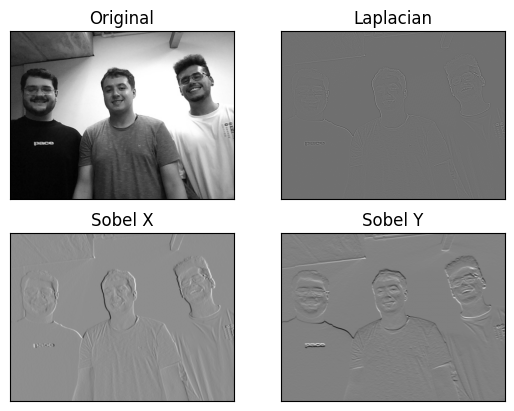

In [9]:
show_images(img, *filtering(img))
save_images(*filtering(img), 'foto-geral')

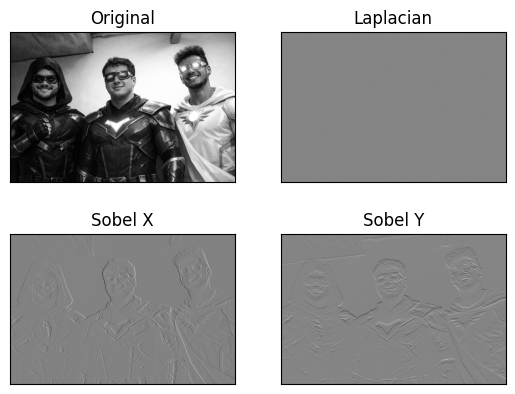

In [10]:
show_images(img2, *filtering(img2))
save_images(*filtering(img2), 'avatar')

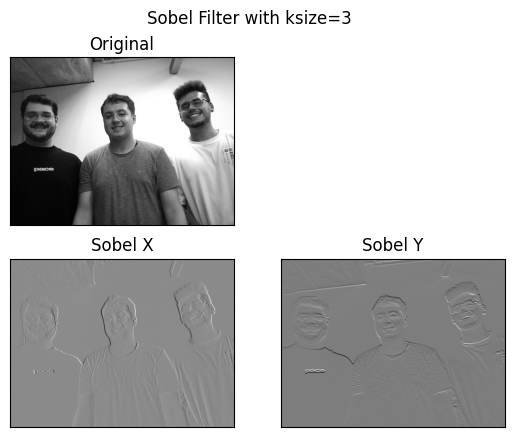

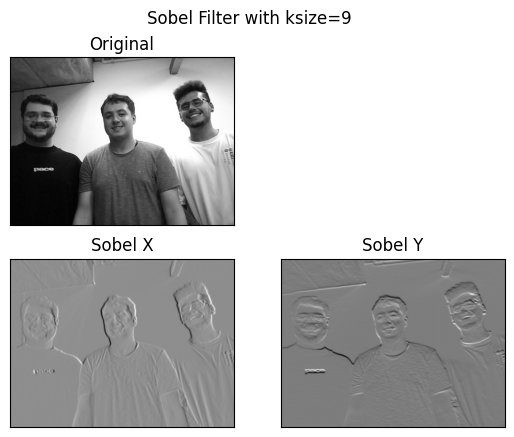

In [11]:
k = [3,9]

for k in k:
    sobel_filter(img, ksize=k)

### Teste do filtro: Canny Edge

In [12]:
def canny_filter(img, low_threshold, high_threshold):
    edges = cv.Canny(img,low_threshold,high_threshold)
    plt.subplot(121),plt.imshow(img,cmap = 'gray')
    plt.title('Original Image'), plt.xticks([]), plt.yticks([])
    plt.subplot(122),plt.imshow(edges,cmap = 'gray')
    plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
    plt.suptitle(f'Canny Edge Detection with low_threshold={low_threshold} and high_threshold={high_threshold}')
    plt.show()

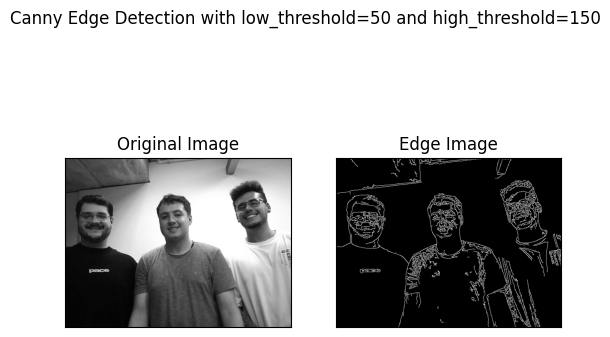

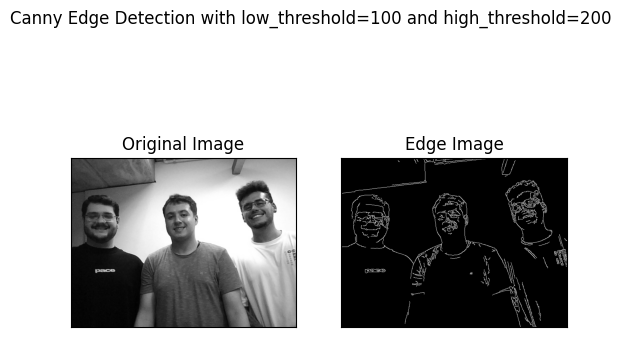

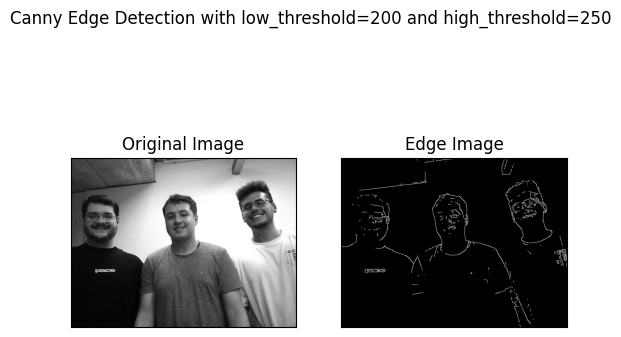

In [13]:
variacoes = [
    (50, 150),
    (100, 200),
    (200, 250)
]

for low, high in variacoes:
    canny_filter(img, low, high)

# 2. Testando nitidez da imagem

In [13]:
img_ruidosa = cv.imread('../parte-A/imagens/ruido_gaussiano.jpg', cv.IMREAD_GRAYSCALE)

In [14]:
def save_new_images(name, img):
    cv.imwrite(f'new_images/nitidez_{name}.jpg', img)

### Utilizando: Laplace

In [14]:
def laplacian_sharpening(img, c=-1):
    img_float = np.float64(img)
    laplacian = cv.Laplacian(img_float, cv.CV_64F)
    g = img_float + (c * laplacian)
    g = np.clip(g, 0, 255)
    return np.uint8(g)

def compare_laplacian(img_orig, img_ruidosa):
    orig_sharp = laplacian_sharpening(img_orig, c=-1)
    ruidosa_sharp = laplacian_sharpening(img_ruidosa, c=-1)
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    axs[0, 0].imshow(img_orig, cmap='gray')
    axs[0, 0].set_title('Original')
    axs[0, 0].axis('off')
    
    axs[0, 1].imshow(orig_sharp, cmap='gray')
    axs[0, 1].set_title('Original + Laplaciano')
    axs[0, 1].axis('off')
    
    axs[1, 0].imshow(img_ruidosa, cmap='gray')
    axs[1, 0].set_title('Ruidosa')
    axs[1, 0].axis('off')
    
    axs[1, 1].imshow(ruidosa_sharp, cmap='gray')
    axs[1, 1].set_title('Ruidosa + Laplaciano')
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

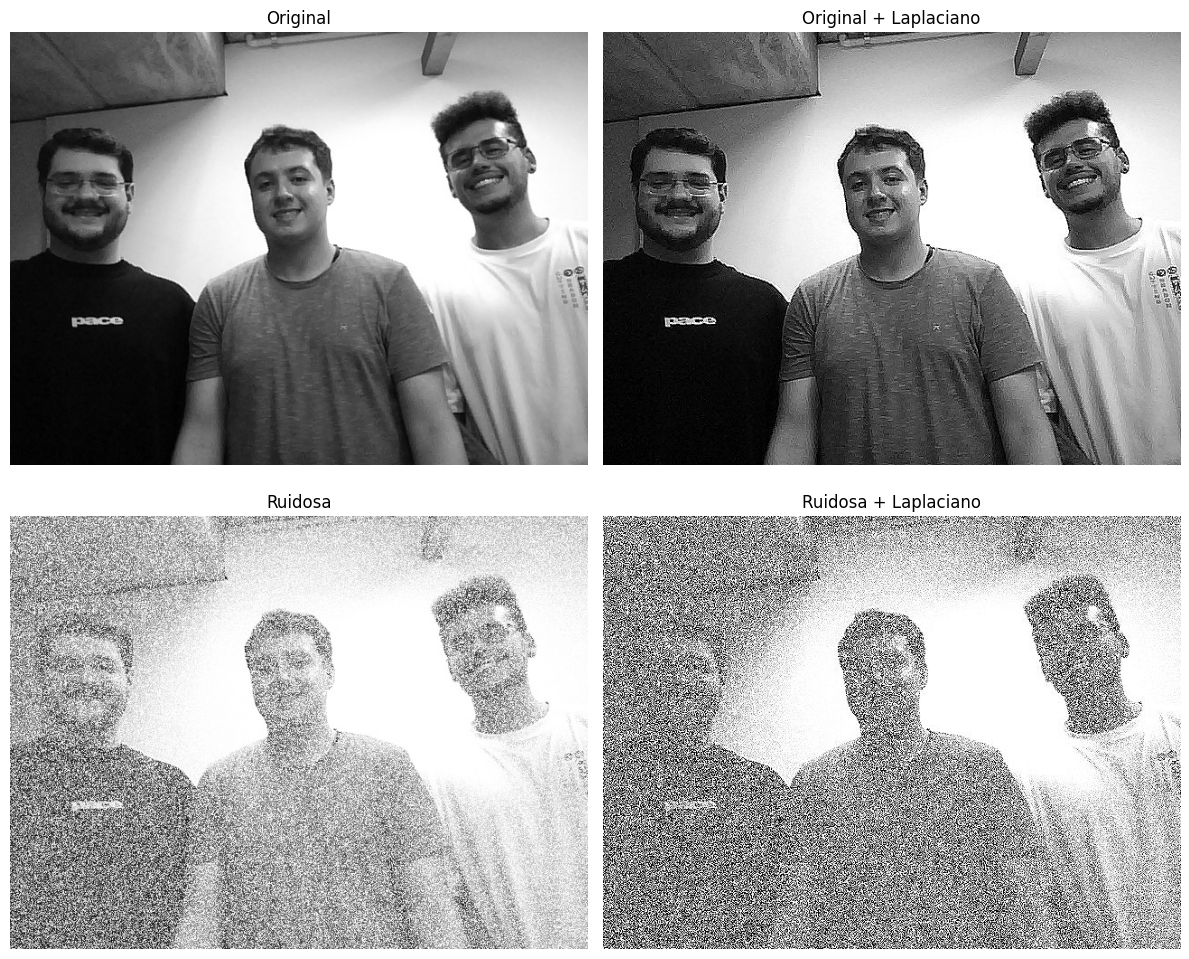

In [17]:
compare_laplacian(img, img_ruidosa)
save_new_images('laplacian_foto_geral', laplacian_sharpening(img, c=-1))
save_new_images('laplacian_foto_ruidosa', laplacian_sharpening(img_ruidosa, c=-1))

### Utilizando: Highboost

In [15]:
def highboost_filter(img, k_levels=[1.5, 3.0]):
    img_float = np.float64(img)    
    blurred = cv.GaussianBlur(img_float, (5, 5), 0)
    mask = img_float - blurred
    
    results = []
    for k in k_levels:
        g = img_float + (k * mask)
        g = np.clip(g, 0, 255)
        results.append(np.uint8(g))
        
    return results

def compare_highboost(img_orig):
    k_levels = [1.5, 3.0]
    results = highboost_filter(img_orig, k_levels)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_orig, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    for i, k in enumerate(k_levels):
        plt.subplot(1, 3, i + 2)
        plt.imshow(results[i], cmap='gray')
        plt.title(f'Highboost k={k}')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    

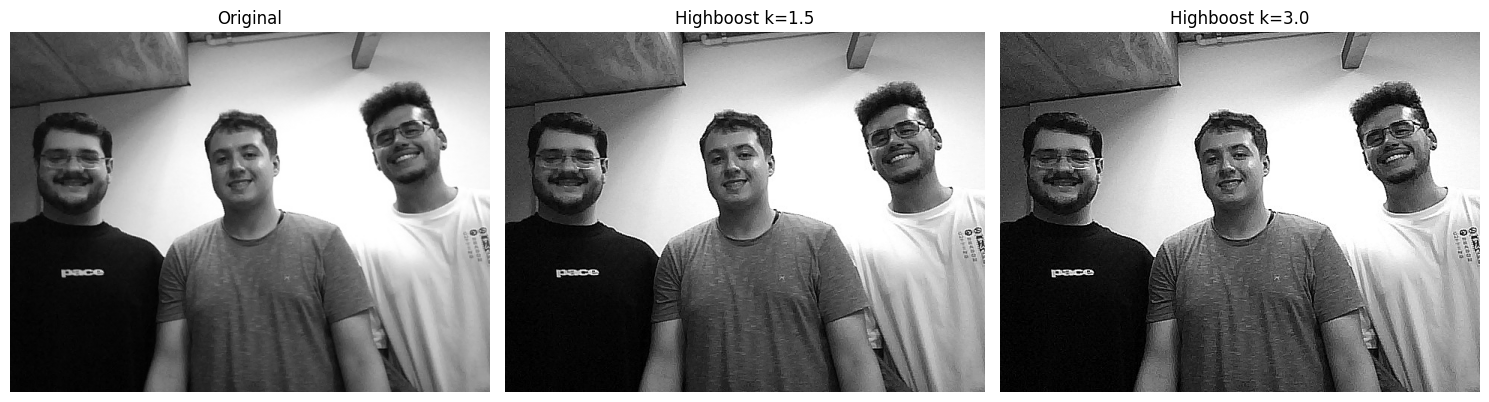

In [19]:
compare_highboost(img)
save_new_images('highboost_foto_geral_k1.5', highboost_filter(img, k_levels=[1.5])[0])

In [17]:
import os
from datetime import datetime

os.makedirs('new_images', exist_ok=True)

def process_webcam_frame(frame, lap_c=-2.0, hb_k=6.0):
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Reaproveita as funcoes anteriores com parametros mais fortes.
    nitidez = laplacian_sharpening(gray, c=lap_c)
    highboost = highboost_filter(gray, k_levels=[hb_k])[0]

    # Diferenca absoluta para visualizar o quanto cada metodo alterou a imagem.
    diff_nitidez = cv.absdiff(gray, nitidez)
    diff_highboost = cv.absdiff(gray, highboost)
    diff_nitidez_vis = cv.normalize(diff_nitidez, None, 0, 255, cv.NORM_MINMAX)
    diff_highboost_vis = cv.normalize(diff_highboost, None, 0, 255, cv.NORM_MINMAX)

    return gray, nitidez, highboost, diff_nitidez_vis, diff_highboost_vis

cap = cv.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError('Nao foi possivel abrir a webcam.')

print("Pressione 's' para salvar as imagens e 'q' para sair.")

while True:
    ret, frame = cap.read()
    if not ret:
        print('Falha ao capturar frame da webcam.')
        break

    original_gray, nitidez_img, highboost_img, diff_nitidez, diff_highboost = process_webcam_frame(
        frame, lap_c=-2.0, hb_k=6.0
    )

    cv.imshow('Webcam Original (Cinza)', original_gray)
    cv.imshow('Nitidez - Laplaciano (c=-2.0)', nitidez_img)
    cv.imshow('Highboost (k=6.0)', highboost_img)
    cv.imshow('Diferenca |Original - Nitidez|', diff_nitidez)
    cv.imshow('Diferenca |Original - Highboost|', diff_highboost)

    key = cv.waitKey(1) & 0xFF
    if key == ord('s'):
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        cv.imwrite(f'new_images/webcam_original_{timestamp}.jpg', original_gray)
        cv.imwrite(f'new_images/webcam_nitidez_laplaciano_{timestamp}.jpg', nitidez_img)
        cv.imwrite(f'new_images/webcam_highboost_{timestamp}.jpg', highboost_img)
        cv.imwrite(f'new_images/webcam_diff_nitidez_{timestamp}.jpg', diff_nitidez)
        cv.imwrite(f'new_images/webcam_diff_highboost_{timestamp}.jpg', diff_highboost)
        print(f'Imagens salvas com sufixo {timestamp}.')
    elif key == ord('q'):
        break

cap.release()
cv.destroyAllWindows()

Pressione 's' para salvar as imagens e 'q' para sair.
Imagens salvas com sufixo 20260315_184900.
Imagens salvas com sufixo 20260315_184906.
